# Aufgabe 4.2 - GenAI & LLM: Semantisches Clustering

Dieses Notebook erzeugt Embeddings über eine externe OpenAI-kompatible Embeddings-API und clustert SMS nach semantischer Ähnlichkeit. Embeddings werden lokal gecacht, damit spätere Runs nachvollziehbar und günstig bleiben.

In [5]:
from pathlib import Path
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from dotenv import load_dotenv
from openai import OpenAI
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import normalize

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 160)

load_dotenv()

DATA_PATH = Path("data/01_cleaned/sms_cleaned.csv")
CACHE_DIR = Path("data/01_cleaned")
EMBEDDING_MODEL = os.getenv("OPENAI_EMBEDDING_MODEL", "text-embedding-3-small")
EMBEDDING_CACHE = CACHE_DIR / f"sms_embeddings_{EMBEDDING_MODEL.replace('/', '_')}.npy"
RANDOM_STATE = 42

## Verwendete APIs, Modelle und Bibliotheken

- API/Dienst: OpenAI-kompatible Embeddings-API.
- Default-Modell: `text-embedding-3-small`, per `OPENAI_EMBEDDING_MODEL` überschreibbar.
- Authentifizierung: `OPENAI_API_KEY` in Environment oder `.env`.
- Optionaler Endpoint: `OPENAI_BASE_URL`, falls ein kompatibler Provider genutzt wird.
- Libraries: `openai`, `python-dotenv`, `pandas`, `numpy`, `scikit-learn`, `matplotlib`, `seaborn`.

Warum Embeddings: Bag-of-Words erkennt Wortüberschneidungen, aber keine semantische Nähe. Embeddings bilden komplette SMS als dichte Vektoren ab, wodurch ähnliche Absichten und Themen auch bei anderer Wortwahl näher zusammenliegen.

In [6]:
df = pd.read_csv(DATA_PATH, encoding="utf-8")
display(df.head())
display(df["label"].value_counts().to_frame("count"))

,label,target,message
0,ham,0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,0,Ok lar... Joking wif u oni...
2,spam,1,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
3,ham,0,U dun say so early hor... U c already then say...
4,ham,0,"Nah I don't think he goes to usf, he lives around here though"


,count
label,
ham,4516
spam,642


## Embeddings erzeugen oder aus Cache laden

Der Cache ist bewusst Teil von `data/01_cleaned`, weil er aus dem bereinigten Datensatz abgeleitet ist. Wenn das Modell gewechselt wird, entsteht automatisch ein separater Cache-Dateiname.

In [7]:
def embed_texts(texts, model=EMBEDDING_MODEL, batch_size=128, sleep_seconds=0.0):
    client_kwargs = {"api_key": os.getenv("OPENAI_API_KEY")}
    if os.getenv("OPENAI_BASE_URL"):
        client_kwargs["base_url"] = os.getenv("OPENAI_BASE_URL")
    client = OpenAI(**client_kwargs)
    vectors = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start : start + batch_size]
        response = client.embeddings.create(model=model, input=batch)
        vectors.extend([item.embedding for item in response.data])
        print(f"Embedded {min(start + batch_size, len(texts))}/{len(texts)}")
        if sleep_seconds:
            time.sleep(sleep_seconds)
    return np.asarray(vectors, dtype=np.float32)

if EMBEDDING_CACHE.exists():
    embeddings = np.load(EMBEDDING_CACHE)
    print(f"Loaded cached embeddings: {EMBEDDING_CACHE} {embeddings.shape}")
else:
    if not os.getenv("OPENAI_API_KEY"):
        raise RuntimeError("OPENAI_API_KEY ist nicht gesetzt. Bitte .env anlegen oder Environment Variable setzen.")
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    embeddings = embed_texts(df["message"].tolist())
    np.save(EMBEDDING_CACHE, embeddings)
    print(f"Saved embeddings: {EMBEDDING_CACHE} {embeddings.shape}")

if embeddings.shape[0] == len(df):
    print(f"Embedding rows match dataset rows: {embeddings.shape[0]}")
else:
    print(f"WARNING: Embedding count {embeddings.shape[0]} does not match row count {len(df)}")

Embedded 128/5158
Embedded 256/5158
Embedded 384/5158
Embedded 512/5158
Embedded 640/5158
Embedded 768/5158
Embedded 896/5158
Embedded 1024/5158
Embedded 1152/5158
Embedded 1280/5158
Embedded 1408/5158
Embedded 1536/5158
Embedded 1664/5158
Embedded 1792/5158
Embedded 1920/5158
Embedded 2048/5158
Embedded 2176/5158
Embedded 2304/5158
Embedded 2432/5158
Embedded 2560/5158
Embedded 2688/5158
Embedded 2816/5158
Embedded 2944/5158
Embedded 3072/5158
Embedded 3200/5158
Embedded 3328/5158
Embedded 3456/5158
Embedded 3584/5158
Embedded 3712/5158
Embedded 3840/5158
Embedded 3968/5158
Embedded 4096/5158
Embedded 4224/5158
Embedded 4352/5158
Embedded 4480/5158
Embedded 4608/5158
Embedded 4736/5158
Embedded 4864/5158
Embedded 4992/5158
Embedded 5120/5158
Embedded 5158/5158
Saved embeddings: data\01_cleaned\sms_embeddings_text-embedding-3-small.npy (5158, 1536)
Embedding rows match dataset rows: 5158


Embeddings werden L2-normalisiert, damit KMeans stärker auf Richtung/semantische Ähnlichkeit und weniger auf Vektorlänge reagiert.

,k,silhouette,inertia
0,2,0.0309,4029.4851
1,3,0.0249,3962.0610
2,4,0.0254,3913.7747
3,5,0.0241,3878.5239
4,6,0.0229,3846.3481
5,7,0.0221,3822.2095
6,8,0.0205,3799.1904
7,9,0.0137,3776.8311
8,10,0.0148,3759.0205
9,11,0.0152,3743.1609


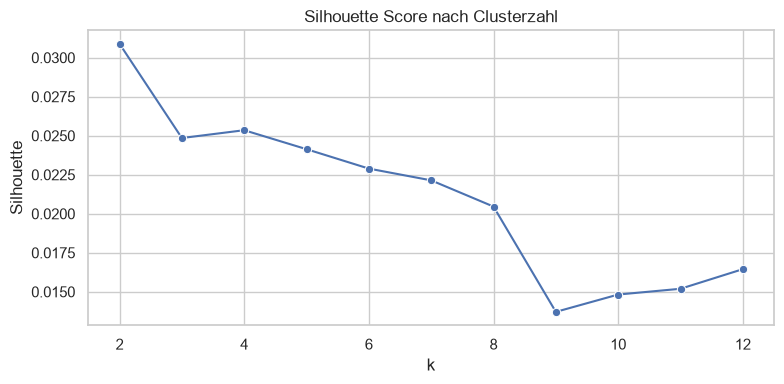

In [8]:
X = normalize(embeddings)

scores = []
for k in range(2, 13):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels, metric="euclidean")
    scores.append({"k": k, "silhouette": score, "inertia": model.inertia_})

scores_df = pd.DataFrame(scores)
display(scores_df.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=scores_df, x="k", y="silhouette", marker="o", ax=ax)
ax.set_title("Silhouette Score nach Clusterzahl")
ax.set_xlabel("k")
ax.set_ylabel("Silhouette")
plt.tight_layout()

In [9]:
best_k = int(scores_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
print(f"Gewählte Clusterzahl nach Silhouette: k={best_k}")

cluster_model = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df_clustered = df.copy()
df_clustered["cluster"] = cluster_model.fit_predict(X)

cluster_summary = pd.crosstab(df_clustered["cluster"], df_clustered["label"], margins=True)
display(cluster_summary)

Gewählte Clusterzahl nach Silhouette: k=2


label,ham,spam,All
cluster,,,
0,51,613,664
1,4465,29,4494
All,4516,642,5158


## Cluster interpretieren

Zur Interpretation werden pro Cluster die nächsten SMS zum Clusterzentrum und häufige Begriffe angezeigt. Das ist wichtig, weil Clustering unüberwacht ist und Cluster keine automatischen Namen haben.

In [10]:
distances = euclidean_distances(X, cluster_model.cluster_centers_)

representatives = []
for cluster_id in sorted(df_clustered["cluster"].unique()):
    idx = np.where(df_clustered["cluster"].to_numpy() == cluster_id)[0]
    nearest = idx[np.argsort(distances[idx, cluster_id])[:5]]
    representatives.append(df_clustered.iloc[nearest][["cluster", "label", "message"]])

display(pd.concat(representatives).reset_index(drop=True))

,cluster,label,message
0,0,spam,"URGENT! Your mobile No *********** WON a £2,000 Bonus Caller Prize on 02/06/03! This is the 2nd attempt to reach YOU! Call 09066362220 ASAP! BOX97N7QP, 150ppm"
1,0,spam,"URGENT! Your mobile No 077xxx WON a £2,000 Bonus Caller Prize on 02/06/03! This is the 2nd attempt to reach YOU! Call 09066362206 ASAP! BOX97N7QP, 150ppm"
2,0,spam,"URGENT! Your mobile was awarded a £1,500 Bonus Caller Prize on 27/6/03. Our final attempt 2 contact U! Call 08714714011"
3,0,spam,"URGENT! Your mobile No 07xxxxxxxxx won a £2,000 bonus caller prize on 02/06/03! this is the 2nd attempt to reach YOU! call 09066362231 ASAP! BOX97N7QP, 150PPM"
4,0,spam,URGENT! Your Mobile number has been awarded with a £2000 prize GUARANTEED. Call 09061790121 from land line. Claim 3030. Valid 12hrs only 150ppm
5,1,ham,U can call me now...
6,1,ham,Ok i msg u b4 i leave my house.
7,1,ham,I tot it's my group mate... Lucky i havent reply... Wat time do ü need to leave...
8,1,ham,Ok i thk i got it. Then u wan me 2 come now or wat?
9,1,ham,K sure am in my relatives home. Sms me de. Pls:-)


In [11]:
def top_cluster_terms(messages, top_n=12):
    vectorizer = CountVectorizer(stop_words="english", lowercase=True, token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z']+\b", min_df=2)
    matrix = vectorizer.fit_transform(messages)
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()
    return ", ".join(pd.DataFrame({"term": terms, "count": counts}).sort_values("count", ascending=False).head(top_n)["term"])

term_summary = (
    df_clustered.groupby("cluster")
    .agg(size=("message", "size"), spam_share=("target", "mean"), top_terms=("message", top_cluster_terms))
    .reset_index()
)
term_summary["spam_share"] = term_summary["spam_share"].round(3)
display(term_summary)

,cluster,size,spam_share,top_terms
0,0,664,0.923,"free, txt, ur, mobile, stop, text, claim, reply, www, prize, just, cash"
1,1,4494,0.006,"i'm, just, ok, got, know, like, good, come, ur, time, love, day"


## 2D-Visualisierung

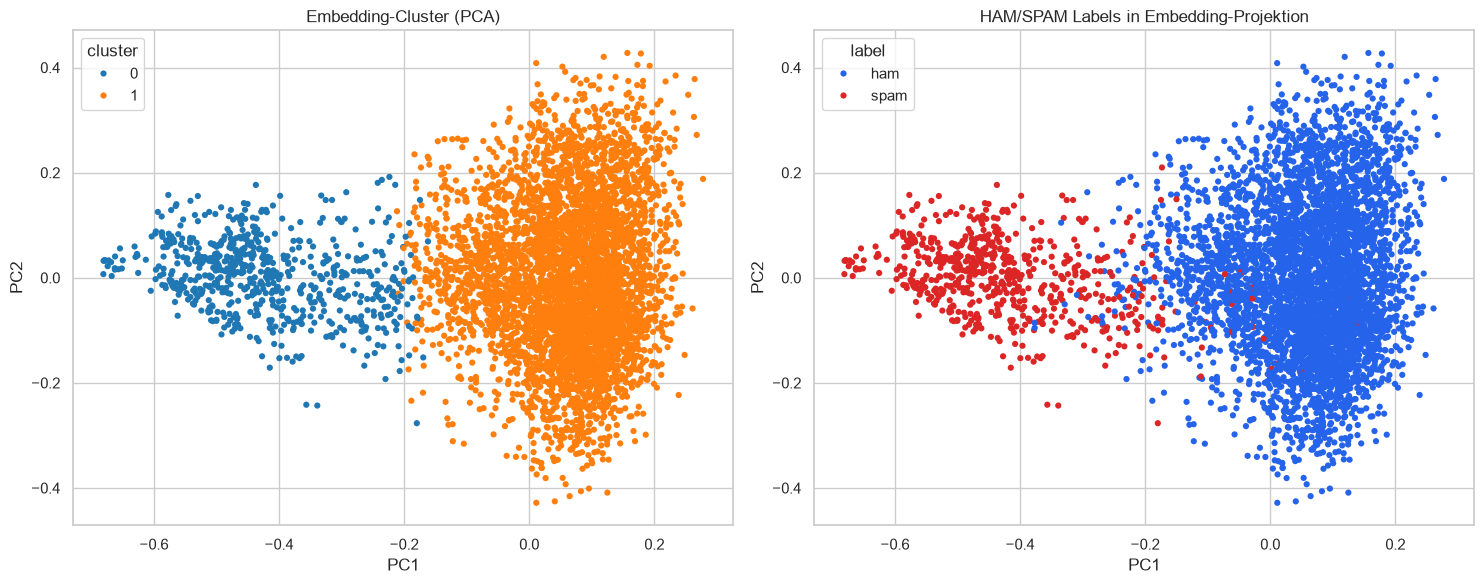

In [16]:
projection = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
plot_df = df_clustered.assign(x=projection[:, 0], y=projection[:, 1])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(data=plot_df, x="x", y="y", hue="cluster", palette="tab10", s=20, linewidth=0, ax=axes[0])
axes[0].set_title("Embedding-Cluster (PCA)")
sns.scatterplot(data=plot_df, x="x", y="y", hue="label", palette={"ham": "#2563eb", "spam": "#dc2626"}, s=20, linewidth=0, ax=axes[1])
axes[1].set_title("HAM/SPAM Labels in Embedding-Projektion")
for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
plt.tight_layout()

## Fazit

Dieses Vorgehen clustert nicht nach bekannten HAM/SPAM-Labels, sondern nach semantischer Ähnlichkeit der Texte. Die Label-Verteilung je Cluster dient nur zur nachträglichen Interpretation. Cluster mit hohem SPAM-Anteil zeigen typischerweise Gewinnspiele, Preise, Call-to-Action, Telefonnummern oder Gebührenhinweise; HAM-Cluster enthalten eher persönliche Alltagskommunikation.